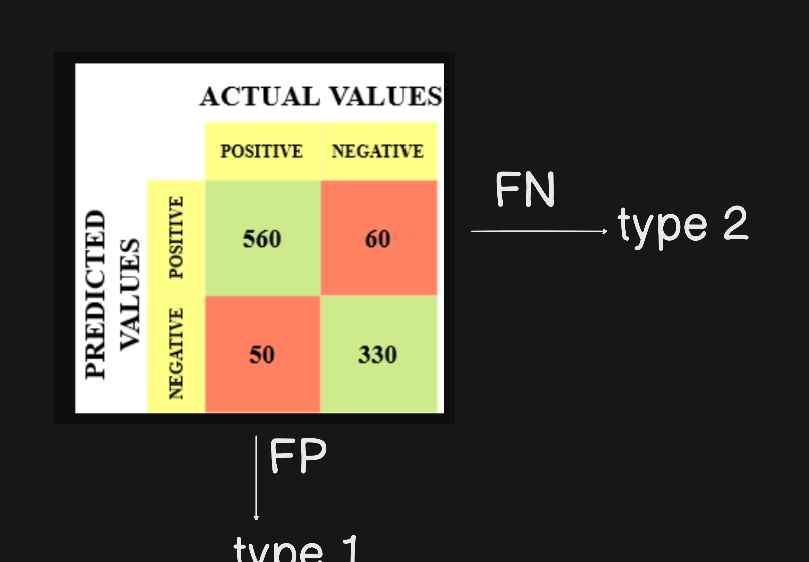

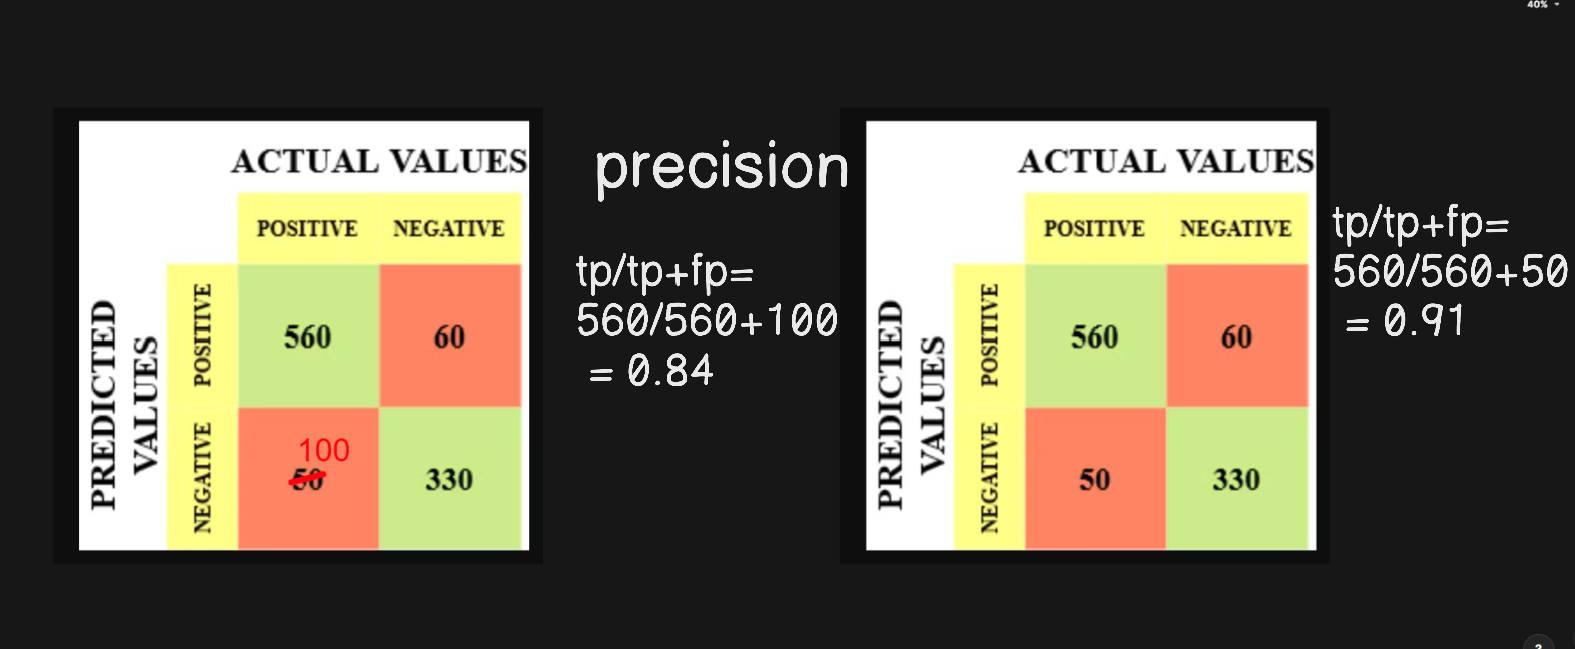

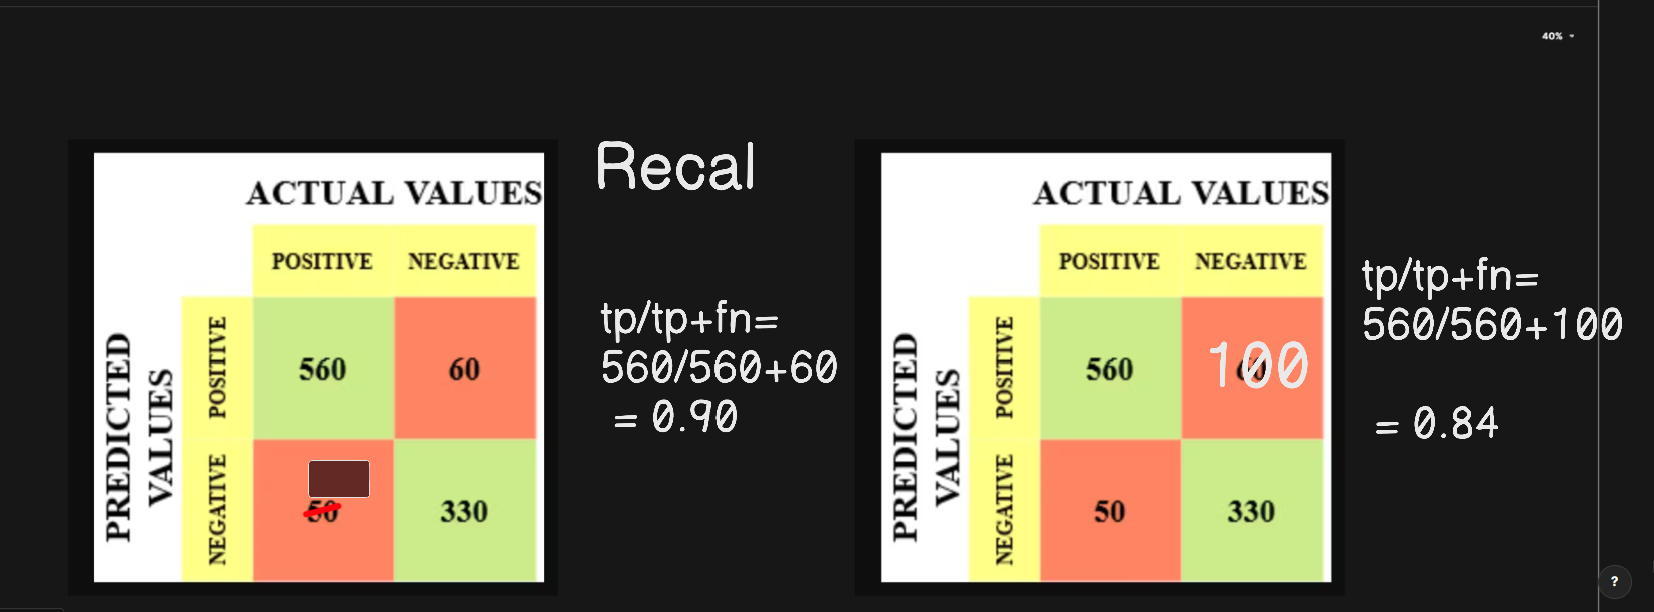

- Type1 error: Email spam me chala gya lekin wo span nai tha (True bolke ghalt sabit hogya (FP))
- Type2 error: Patient ko bukhar tha lekin hamne bola tmhn bukhar nai hai (False bolke ghalat sabit hogya (FN))
- Precision is used in case of type 1 error (jska precision zida hoga ya FP kam hoga agr confusion matrix ko dekhen us model ko pick krnge)
- Recall is used in case of type 2 error (jska recall ziada hoga or jska FN kam hoga confusion matrix ko agr dekhen, usko pick krnge)
- f1-score = combination of both precision and recall, harmonic mean of precision and recall, jska f1-score ziada hoga, us model ko pick krnge

In [1]:
import pandas as pd
df = pd.read_csv('heart.csv')

In [2]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:-1],df.iloc[:,-1],test_size=0.2,random_state=2)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [5]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [6]:
clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)

c:\Users\SMIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
y_pred1 = clf1.predict(X_test)
y_pred2 = clf2.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score,confusion_matrix
print("Accuracy of Logistic Regression",accuracy_score(y_test,y_pred1))
print("Accuracy of Decision Trees",accuracy_score(y_test,y_pred2))

Accuracy of Logistic Regression 0.9016393442622951
Accuracy of Decision Trees 0.8360655737704918


In [9]:
confusion_matrix(y_test,y_pred1)

array([[26,  6],
       [ 0, 29]])

In [10]:
print("Logistic Regression Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test,y_pred1),columns=list(range(0,2)))

Logistic Regression Confusion Matrix



,0,1
0,26,6
1,0,29


In [11]:
print("Decision Tree Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test,y_pred2),columns=list(range(0,2)))

Decision Tree Confusion Matrix



,0,1
0,24,8
1,2,27


In [12]:
result = pd.DataFrame()
result['Actual Label'] = y_test
result['Logistic Regression Prediction'] = y_pred1
result['Decision Tree Prediction'] = y_pred2

In [14]:
result.sample(10)

,Actual Label,Logistic Regression Prediction,Decision Tree Prediction
169,0,0,0
192,0,0,0
175,0,0,0
184,0,0,0
133,1,1,1
188,0,1,0
11,1,1,1
134,1,1,1
296,0,1,0
164,1,1,1


In [13]:
from sklearn.metrics import recall_score,precision_score,f1_score

In [15]:
print("For Logistic regression Model")
print("-"*50)
cdf = pd.DataFrame(confusion_matrix(y_test,y_pred1),columns=list(range(0,2)))
print(cdf)
print("-"*50)
print("Precision - ",precision_score(y_test,y_pred1))
print("Recall - ",recall_score(y_test,y_pred1))
print("F1 score - ",f1_score(y_test,y_pred1))

For Logistic regression Model
--------------------------------------------------
    0   1
0  26   6
1   0  29
--------------------------------------------------
Precision -  0.8285714285714286
Recall -  1.0
F1 score -  0.90625


In [16]:
print("For DT Model")
print("-"*50)
cdf = pd.DataFrame(confusion_matrix(y_test,y_pred2),columns=list(range(0,2)))
print(cdf)
print("-"*50)
print("Precision - ",precision_score(y_test,y_pred2))
print("Recall - ",recall_score(y_test,y_pred2))
print("F1 score - ",f1_score(y_test,y_pred2))

For DT Model
--------------------------------------------------
    0   1
0  24   8
1   2  27
--------------------------------------------------
Precision -  0.7714285714285715
Recall -  0.9310344827586207
F1 score -  0.84375


In [17]:
precision_score(y_test,y_pred1,average=None)

array([1.        , 0.82857143])

In [ ]:
precision_score(y_test,y_pred2,average=None)

In [ ]:
recall_score(y_test,y_pred2,average=None)